# Data analysis notebook
The objective of this notebook is to explore the statistical properties of daily S&P 500 returns before developing volatility and regime-switching models.

In [34]:
from pathlib import Path
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import sys
import numpy as np
import statsmodels as sm


project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [44]:
from src import data_loader as dl
from src import preprocessing as pp
# Download S&P 500 data from 2000-01-01 and compute daily log returns.
raw_data = dl.load_market_data()
market_data = pp.preprocess_market_data(raw_data).dropna()
print(market_data.head())

                  Close    Return
Date                             
2000-01-04  1399.420044 -0.039099
2000-01-05  1402.109985  0.001920
2000-01-06  1403.449951  0.000955
2000-01-07  1441.469971  0.026730
2000-01-10  1457.599976  0.011128


## Daily closing price of the S&P 500 (2000-Present)

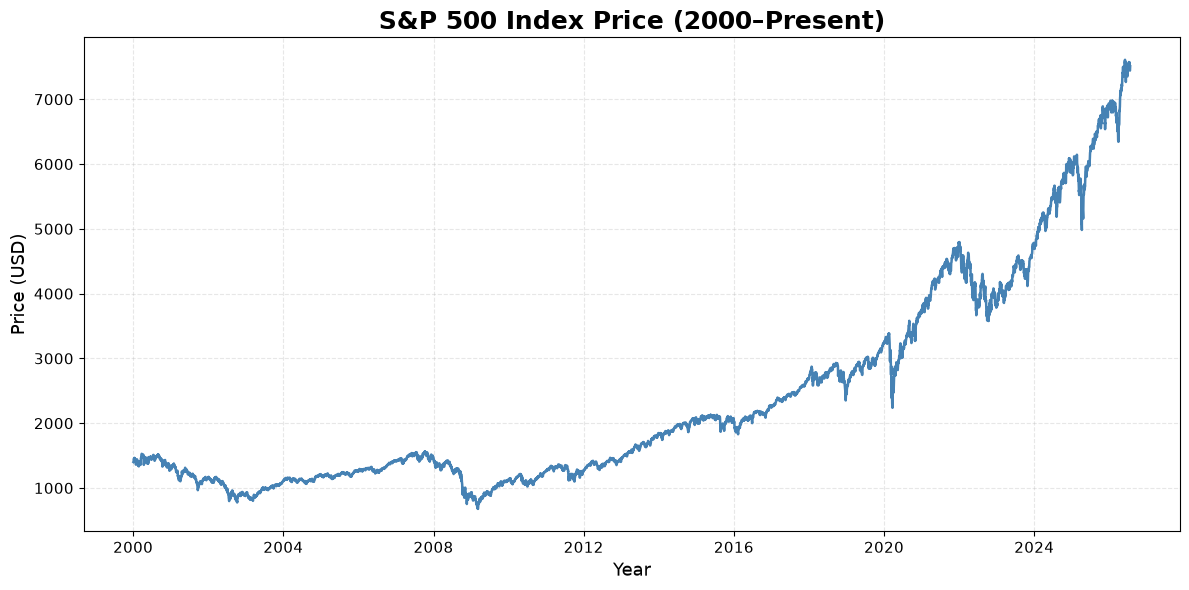

In [45]:
plt.figure(figsize=(12, 6))

plt.plot(market_data.index, market_data["Close"], linewidth=1.8, color="steelblue")

plt.title("S&P 500 Index Price (2000–Present)",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Year", fontsize=13)
plt.ylabel("Price (USD)", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.3)

plt.tick_params(axis="both", labelsize=11)

plt.tight_layout()

plt.show()

### Discussion

The figure shows the S&P 500 price index from 2000 to the present. A long-term upward trend can be observed, with several major market dips, such as the dot-com crash, the 2008 financial crisis, the COVID-19 pandemic, and the 2022 market correction. These episodes suggest that market dynamics are not constant through time and motivate a closer examination of returns and volatility. Since the price series is non-stationary, returns will be used in the subsequent analysis rather than raw prices. Returns normalize performance into a comparable scale, making it possible to apply standard statistical models.

## Daily log returns of the S&P 500 (2000-Present)

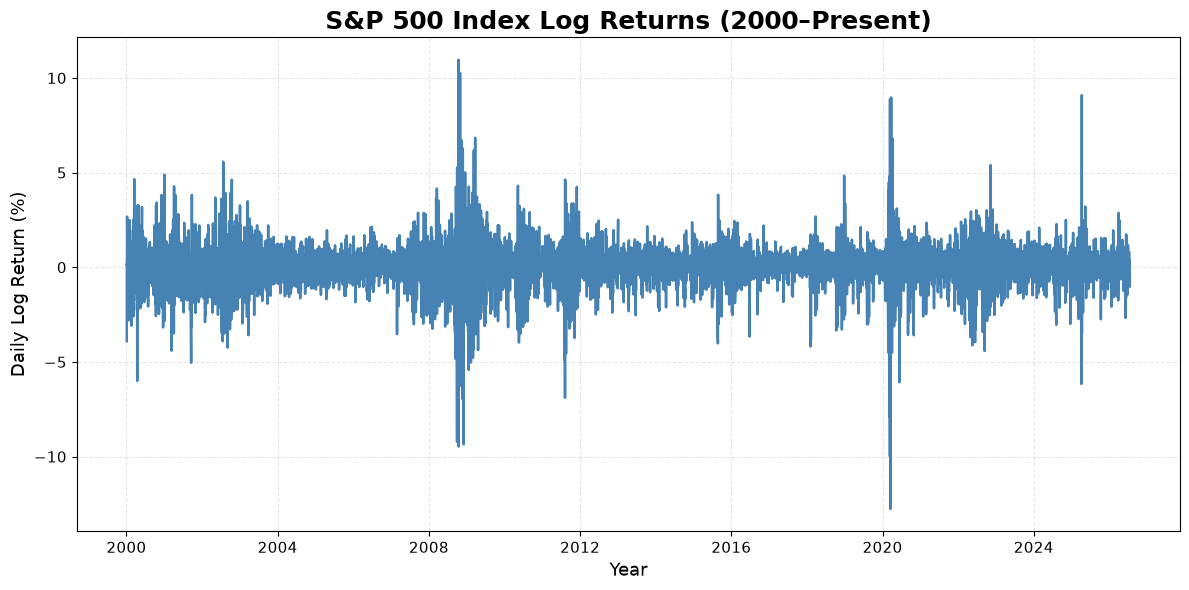

In [5]:
plt.figure(figsize=(12, 6))

plt.plot(market_data.index, market_data["Return"] * 100, linewidth=1.8, color="steelblue")

plt.title("S&P 500 Index Log Returns (2000–Present)",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Year", fontsize=13)
plt.ylabel("Daily Log Return (%)", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.3)

plt.tick_params(axis="both", labelsize=11)

plt.tight_layout()

plt.show()

### Discussion

The daily log returns fluctuate around zero, indicating that the return series is more stationary than the raw price series. Volatility clustering is clearly observable, with large return movements tending to occur in concentrated periods. Several extreme return observations are consistent with major market events, such as the 2008 financial crisis and the COVID-19 market crash in 2020. The figure suggests that market volatility is time-varying rather than constant, motivating the use of conditional volatility models capable of capturing volatility persistence.

## Descriptive Statistics
To obtain an initial understanding of the return series, we compute a set of descriptive statistics. These statistics provide insight into the central tendency, dispersion and shape of the return distribution, allowing us to assess whether the data exhibit characteristics commonly observed in financial markets.

**Table 1. Descriptive statistics of daily S&P 500 log returns (2000–Present).**

In [46]:
returns = market_data["Return"].dropna()
summary = pd.DataFrame({
    "Statistic": [
        "Observations",
        "Mean",
        "Median",
        "Standard Deviation",
        "Skewness",
        "Kurtosis",
        "Maximum",
        "5th Percentile",
        "95th Percentile",
         "Minimum"
        
    ],
    "Value": [
        len(returns),
        round(returns.mean(),5),
        round(returns.median(),5),
        round(returns.std(),5),
        round(skew(returns), 5),
        round(kurtosis(returns), 5),
        round(returns.max(),5),
        round(returns.quantile(0.05), 5),
        round(returns.quantile(0.95),5),
        round(returns.min(),5)
    ]
})

summary


,Statistic,Value
0,Observations,6676.00000
1,Mean,0.00025
2,Median,0.00064
3,Standard Deviation,0.01215
4,Skewness,-0.34885
5,Kurtosis,10.64576
6,Maximum,0.10957
7,5th Percentile,-0.01855
8,95th Percentile,0.01692
9,Minimum,-0.12765


### Discussion

Several interesting characteristics can be seen in the descriptive statistics.

- The average daily return is close to zero, which is expected for a broad equity index over long time horizons.
-  The daily standard deviation of approximately 1.22% indicates substantial day-to-day variability in market returns.
- The skewness of -0.35 suggests that extreme negative returns occur somewhat more frequently than equally large positive returns.
- The estimated kurtosis of 10.64 is considerably higher than the Gaussian benchmark of 3, indicating pronounced heavy-tailed behaviour and a higher probability of extreme market movements than predicted by a normal distribution.
- The minimum and maximum daily returns of −12.77% and 10.96%, respectively, further illustrate the presence of rare but severe market events.
- The 5th percentile of −1.86% indicates that approximately 5% of all trading days experienced daily losses greater than 1.86%.
- Conversely, the 95th percentile of 1.69% shows that only 5% of trading days generated returns exceeding 1.69%.
- The wider downside tail relative to the upside tail provides further evidence of the slight negative skewness observed in the return distribution.

## Return Distribution

The descriptive statistics suggest that the return distribution may deviate from normality. To further investigate this, we visualize the empirical distribution of daily log returns.

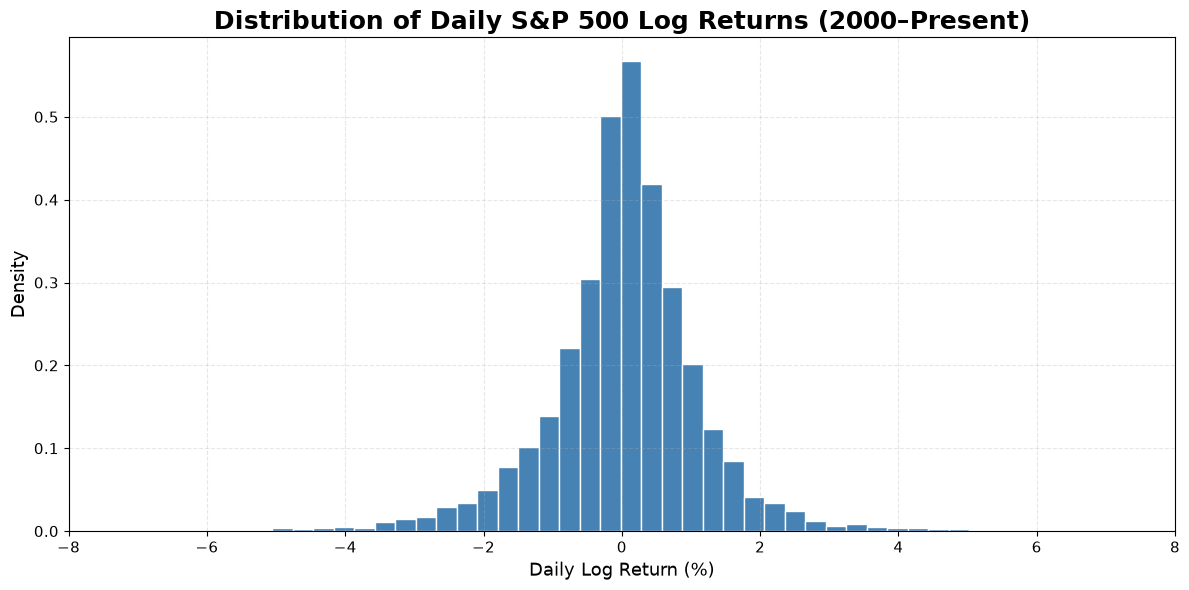

In [20]:
plt.figure(figsize=(12, 6))

plt.hist(market_data["Return"]*100, bins=80, color="steelblue",edgecolor="white",  density = True)

plt.title("Distribution of Daily S&P 500 Log Returns (2000–Present)",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Daily Log Return (%)", fontsize=13)
plt.ylabel("Density", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.3)

plt.tick_params(axis="both", labelsize=11)
plt.xlim(-8, 8)
plt.tight_layout()

plt.show()

### Discussion

The histogram shows that daily log returns are concentrated around zero, indicating that relatively small price movements are most common. Consistent with the descriptive statistics, the empirical distribution appears slightly left-skewed, suggesting that large negative returns occur somewhat more frequently than equally large positive returns. In addition, several observations lie far from the centre of the distribution, indicating the presence of extreme market movements that are unlikely to be captured by a simple Gaussian model.

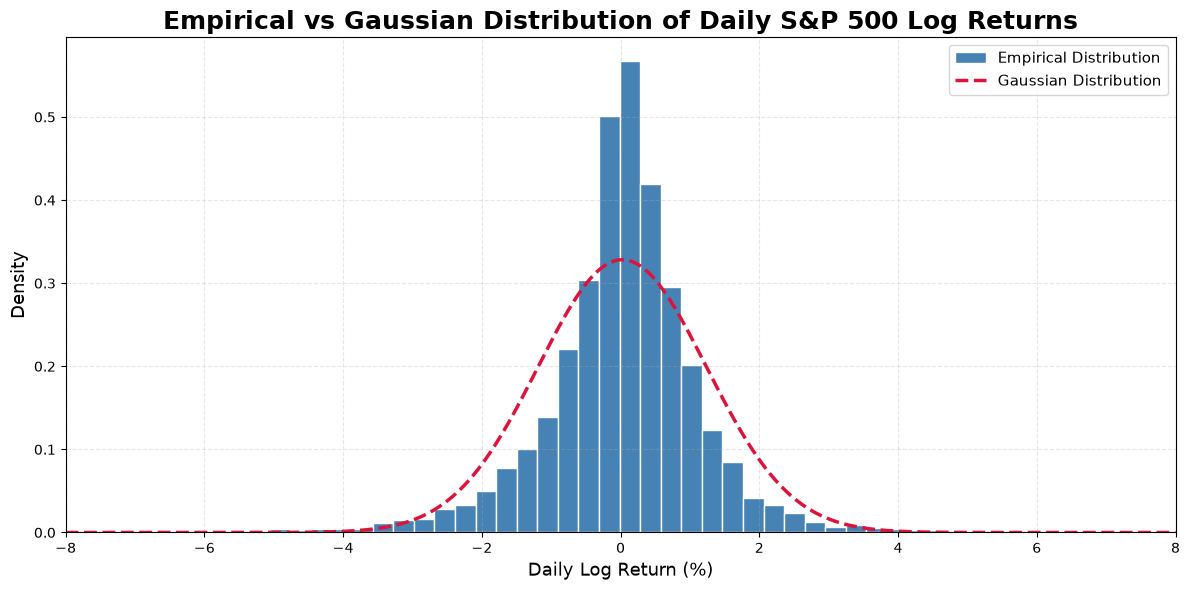

In [30]:
returns = market_data["Return"] * 100
mu = returns.mean()
sigma = returns.std()

# Create x-values for the fitted normal distribution
x = np.linspace(-8, 8, 1000)
pdf = norm.pdf(x, loc=mu, scale=sigma)


plt.figure(figsize=(12, 6))
plt.hist( returns, bins=80, density=True, color="steelblue", edgecolor="white",
          label="Empirical Distribution")
plt.plot(x, pdf, color="crimson",linewidth=2.5, linestyle="--", label="Gaussian Distribution")

plt.xlim(-8, 8)

plt.title( "Empirical vs Gaussian Distribution of Daily S&P 500 Log Returns",
           fontsize=18, fontweight="bold")

plt.xlabel("Daily Log Return (%)", fontsize=13)
plt.ylabel("Density", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.3)

plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Discussion

The fitted Gaussian distribution captures the centre of the empirical return distribution reasonably well. However, it underestimates both the sharp peak around the mean and the probability of large positive and negative return realizations. These deviations indicate that daily S&P 500 returns could not accuratly be described by a normal distribution. Assuming normally distributed returns would underestimate the likelihood of extreme market movements and therefore underestimate financial risk. This motivates the use of volatility models that can better capture the empirical characteristics of financial return series.

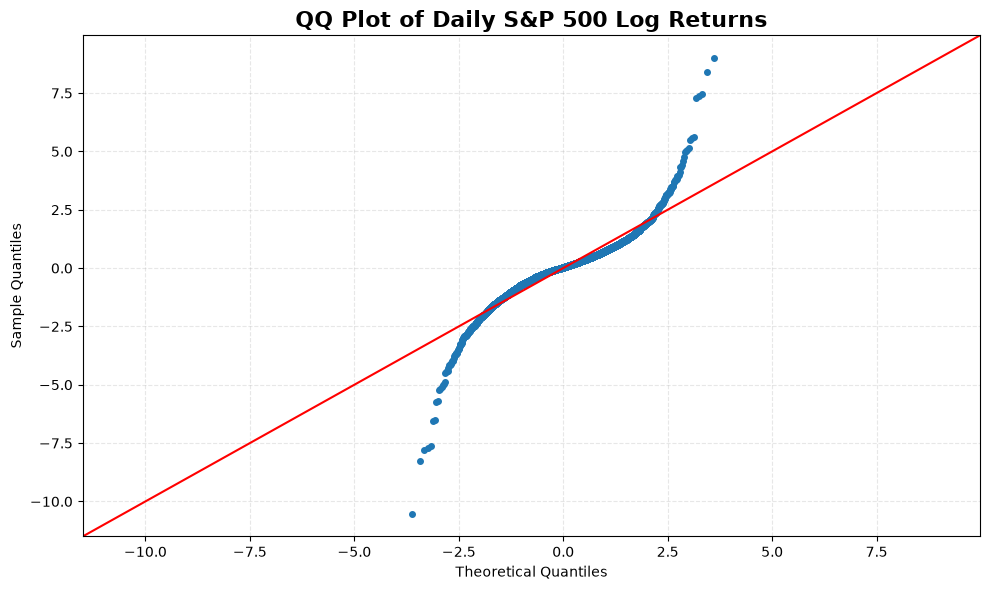

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))

sm.api.qqplot(market_data["Return"], line="45",fit=True,  markersize = 4, ax=ax)
plt.title("QQ Plot of Daily S&P 500 Log Returns", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

The QQ plot illustrates that the empirical return distribution follows the theoretical Gaussian distribution around its centre. However, deviations emerge in both tails, where the empirical quantiles depart substantially from the reference line. The lower tail exhibits slightly stronger deviations than the upper tail, consistent with the negative skewness observed in the descriptive statistics. These findings provide further evidence that daily S&P 500 returns are not adequately described by a Gaussian distribution. While the Gaussian assumption provides an acceptable approximation for typical daily returns, it fails to capture the frequency of extreme market movements. Since financial risk management is primarily concerned with tail events, relying solely on normally distributed returns may lead to underestimation VaR/downside risk.

## Autocorrelation Analysis

While the previous figures suggest that volatility clusters over time, visuals alone is not enough to determine if returns exhibit statistically significant serial dependence. We therefore examine the autocorrelation function (ACF) of both daily log returns and squared log returns. If returns are approximately unpredictable but squared returns remain autocorrelated, this provides strong evidence of volatility persistence and motivates the use of conditional volatility models such as GARCH.

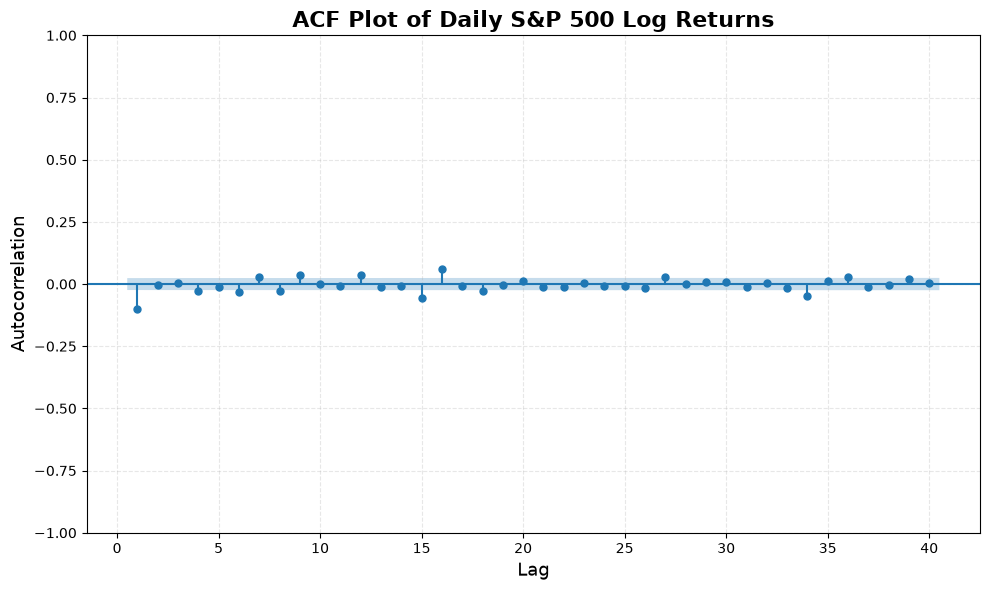

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))

sm.graphics.tsaplots.plot_acf(market_data["Return"], lags=40, alpha=0.05, zero=False, ax=ax)
plt.title("ACF Plot of Daily S&P 500 Log Returns", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3)

ax.set_xlabel("Lag", fontsize=13)
ax.set_ylabel("Autocorrelation", fontsize=13)

ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


### Discussion

The ACF plot demonstrates that autocorrelation coefficients of daily S&P 500 log returns are generally small and concentrated around zero. There are individual lags that extend beyond the approximate 95% confidence interval, their magnitudes remain limited. The most noticeable result is the negative first-order autocorrelation, which sugests a degree of short-term return reversal.

Overall, the figure indicates that past daily returns contain relatively little direct information about future returns. However, the presence of several statistically significant lags means that the return series should not be described as perfectly uncorrelated. The more relevant question is therefore whether dependence exists in the magnitude of returns rather than in their direction. This is examined by analysing the autocorrelation of squared returns.

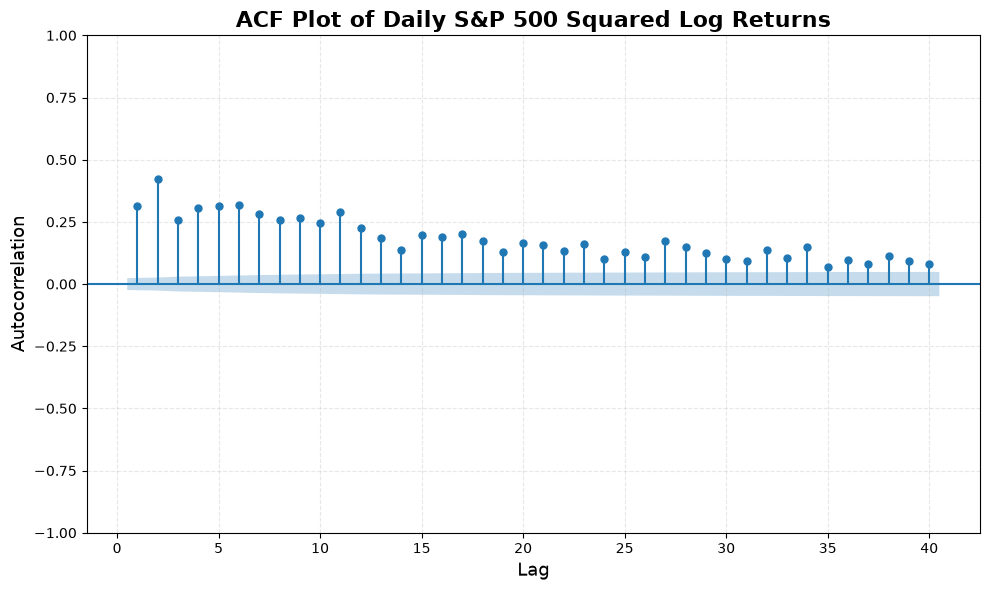

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

sm.graphics.tsaplots.plot_acf(market_data["Return"]**2, lags=40, alpha=0.05, zero=False, ax=ax)
plt.title("ACF Plot of Daily S&P 500 Squared Log Returns", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3)

ax.set_xlabel("Lag", fontsize=13)
ax.set_ylabel("Autocorrelation", fontsize=13)

ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


### Discussion

Unlike the autocorrelation of daily returns, the autocorrelation function of squared returns exhibits strong positive autocorrelation across many lags. The persistence gradually decline rather than disappearing at once, indicating that periods of high volatility tend to be followed by further periods of high volatility. This behaviour is characteristic of volatility clustering and implies that the conditional variance of returns depends on past market conditions rather than remaining constant over time.

While the direction of future returns appears largely unpredictable, the magnitude of future returns exhibits substantial persistence. Consequently, modelling the conditional variance rather than the conditional mean becomes the central objective of financial volatility modelling. This observation indicates conditional heteroskedasticit which motivates the use of ARCH and GARCH models. 

The next stage of the project therefore develops a GARCH model to estimate and forecast conditional volatility. This model will serve as a benchmark before investigating whether latent market regimes can further improve volatility forecasts and dynamic Value-at-Risk estimates.